# RDD

In [1]:
!pip install -r requirements.txt

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.6/14.6 MB 87.8 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 37.8 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 83.2 MB/s  0:00:00
  Attempting uninstall: botocore━━━╸━━━━━━━━━━━━  9/13 [py7zr]todomex]
    Found existing installation: botocore 1.42.30m━━━━━━━━━━━━  9/13 [py7zr]
    Uninstalling botocore-1.42.30:m╸━━━━━━━━━━━━  9/13 [py7zr]
      Successfully uninstalled botocore-1.42.30╸━━━━━━━━━ 10/13 [botocore]
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13/13 [boto3]m12/13 [boto3]re]
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
aiobotocore 3.1.1 requires botocore<1.42.31,>=1.41.0, but you have botocore 1.42.39 which is incompatible.


## [A REPRENDRE] statistiques descriptives et graphiques

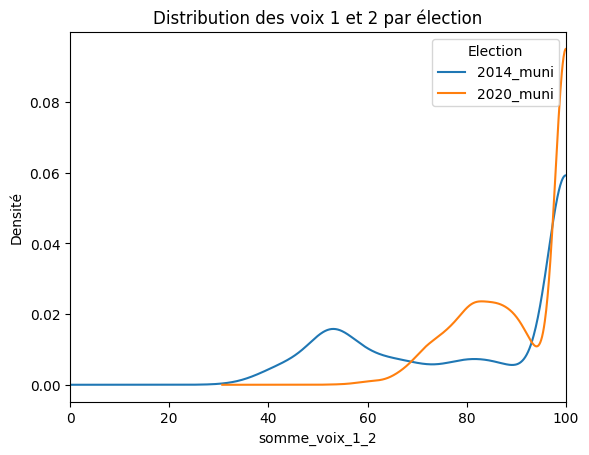

In [ ]:
import matplotlib.pyplot as plt
for c, g in df_vote.groupby("election"):
    (g["rang1_voix_pct"] + g["rang2_voix_pct"]).dropna().plot(
        kind="kde",RDD
        label=str(c)
    )
plt.xlabel("somme_voix_1_2")
plt.ylabel("Densité")
plt.xlim(0, 100)
plt.title("Distribution des voix 1 et 2 par élection")
plt.legend(title="Election")
plt.show()

In [6]:
df_vote.groupby(["election","rang1_Nuance"]).size()

election   rang1_Nuance
2014_muni  -1.0            2935
            0.0            1652
            1.0            4631
2020_muni  -1.0             947
            0.0             411
            1.0            1686
dtype: int64

# IMPORT BASE RDD_main

In [7]:
import os 
import pandas as pd
from functions.basic_functions import load_gpkg
from functions.s3_connexion import get_s3

#vote
remote_path="RDD/df_RDD_main_BC_full.csv"
local_path = f"/tmp/{os.path.basename(remote_path)}"
get_s3().download_file("mgarbe", remote_path, local_path)
gdf_RDD=pd.read_csv(local_path, sep=";")

In [8]:
gdf_RDD

,election,Code INSEE,rang1_Nuance,delta_score_1,Nuance_interco,nb_permis,surface_creee,surface_moyenne,BC_pop,BC_taux_chom,BC_taux_emploi,BC_dens_pop
0,2014_muni,01004,1.0,39.583333,NaN,0.0,0.0,0.000000,13839,NaN,71.2,562.56
1,2014_muni,01007,-1.0,-5.291411,NaN,0.0,0.0,0.000000,2365,NaN,74.8,70.60
2,2014_muni,01024,1.0,18.309859,-1.0,0.0,0.0,0.000000,3023,NaN,79.9,161.66
3,2014_muni,01027,1.0,44.155844,1.0,0.0,0.0,0.000000,2498,NaN,85.6,138.78
4,2014_muni,01031,-1.0,-20.638086,1.0,0.0,0.0,0.000000,3590,NaN,67.5,460.26
...,...,...,...,...,...,...,...,...,...,...,...,...
2791,2020_muni,95488,-1.0,-29.800000,1.0,2.0,13853.0,6926.500000,8168,9.8,70.3,887.83
2792,2020_muni,95572,-1.0,-14.572048,-1.0,18.0,113284.0,6293.555556,24087,11.9,72.9,1974.34
2793,2020_muni,95607,1.0,22.312679,1.0,10.0,30134.0,3013.400000,26296,9.5,74.2,2504.38
2794,2020_muni,95612,1.0,12.844910,1.0,7.0,37614.0,5373.428571,4427,12.9,71.6,1135.13


## Des cartes

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import geopandas as gpd

# =========================
# 1. Charger le GeoJSON compressé
# =========================
chemin_geojson = "/home/onyxia/work/projet3A/donnees_electorales/communes-50m.geojson.gz"

communes = gpd.read_file(
    f"/vsigzip/{chemin_geojson}",
    driver="GeoJSON"
)
# Colonnes utiles (à adapter si besoin)
communes = communes[["code", "nom", "geometry"]]

# S'assurer que le code INSEE est bien une chaîne
communes["code"] = communes["code"].astype(str)


# =========================
# 3. Jointure communes ↔ données
# =========================
carte_vote = communes.merge(gdf_RDD,left_on="code",right_on="Code INSEE", how="left")
carte_vote_complete = carte_vote.dropna(subset=["rang1_Nuance"])
carte_vote_complete_2014 = carte_vote_complete[carte_vote_complete["election"] == "2014_muni"]


DataSourceError: '/vsigzip//home/onyxia/work/projet3A/donnees_electorales/communes-50m.geojson.gz' does not exist in the file system, and is not recognized as a supported dataset name.

In [10]:
carte_vote_complete_2014.head()

NameError: name 'carte_vote_complete_2014' is not defined

NameError: name 'carte_vote_complete_2014' is not defined

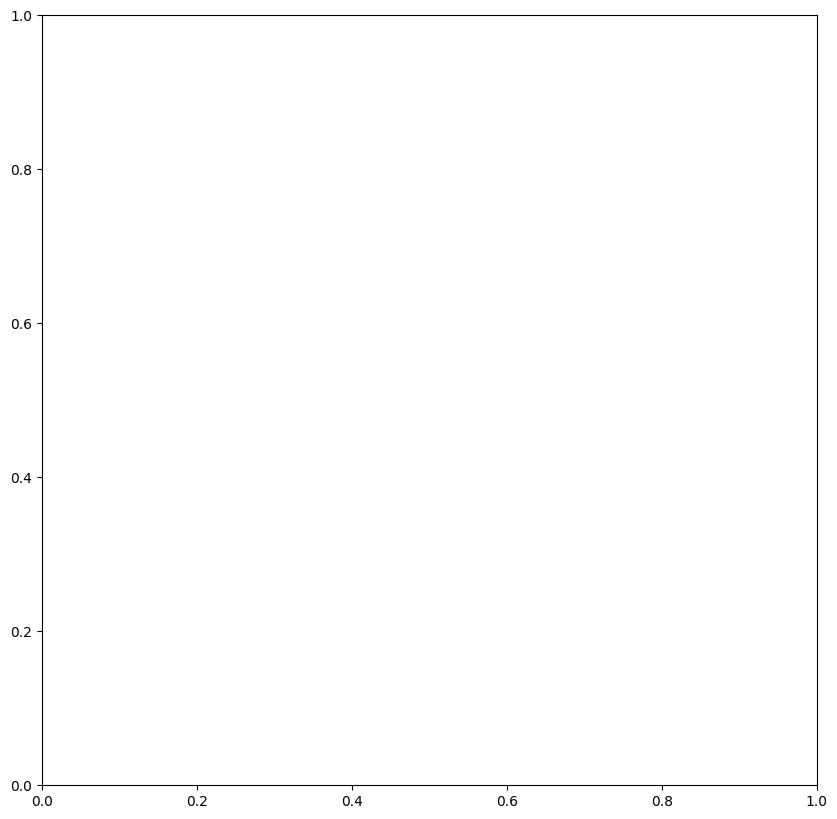

In [11]:
from matplotlib.colors import ListedColormap
cmap = ListedColormap(["red", "blue"])
fig, ax = plt.subplots(1, 1, figsize=(10, 10))

carte_vote_complete_2014.plot(
    column="rang1_Nuance",
    categorical=True,
    cmap=cmap,
    legend=True,
    ax=ax,
    missing_kwds={
        "color": "lightgrey",
        "label": "Données manquantes"
    }
)

ax.set_title("Vote par commune", fontsize=14)
ax.axis("off")

plt.show()

## BALANCED CHECKS 

In [12]:
seuil=8
gdf_RDD=gdf_RDD[abs(gdf_RDD["delta_score_1"])<seuil].copy()

In [16]:
print(f"Variables dispo pour BC : {[col for col in gdf_RDD.columns if col.startswith("BC_")]}")

Variables dispo pour BC : ['BC_pop', 'BC_taux_chom', 'BC_taux_emploi', 'BC_dens_pop']


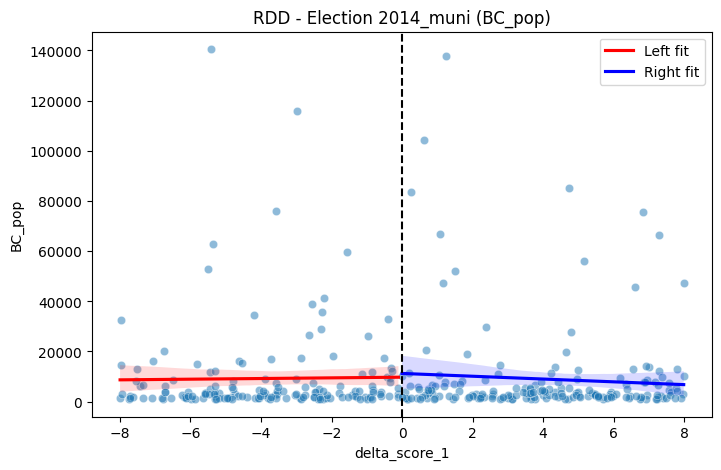

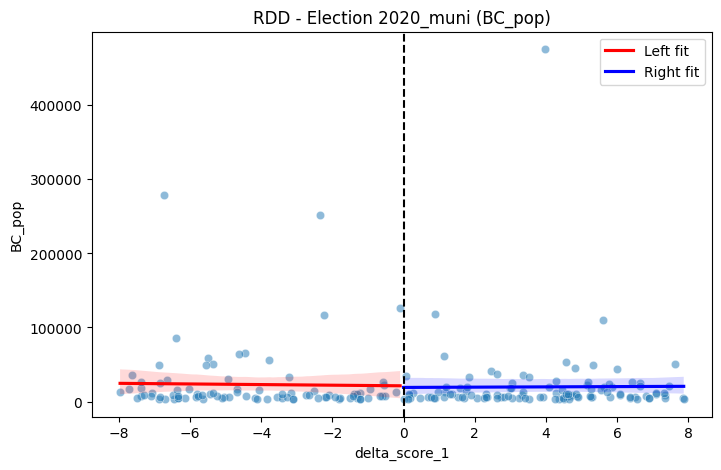

In [22]:
#plots des BC
from functions.RDD_functions import plot_rdd 
var='BC_pop' #changer la variable pour d'autres BC
plot_rdd(gdf_RDD, outcome_var=var)

## RESULTATS 

In [23]:
gdf_RDD.groupby(['election','rang1_Nuance'])['Code INSEE'].nunique().reset_index(name='nb_communes')

,election,rang1_Nuance,nb_communes
0,2014_muni,-1.0,157
1,2014_muni,1.0,186
2,2020_muni,-1.0,89
3,2020_muni,1.0,109


### RDD LINEAIRE

In [35]:
(gdf_RDD[gdf_RDD["election"]=="2014_muni"]["nb_permis"]>0).sum()

np.int64(165)

In [36]:
gdf_RDD.columns

Index(['election', 'Code INSEE', 'rang1_Nuance', 'delta_score_1',
       'Nuance_interco', 'nb_permis', 'surface_creee', 'surface_moyenne'],
      dtype='object')

In [37]:
gdf_RDD.groupby(["election","Nuance_interco"]).size()

election   Nuance_interco
2014_muni  -1.0              116
            0.0               11
            1.0              128
2020_muni  -1.0               64
            0.0               24
            1.0               70
dtype: int64

                            OLS Regression Results                            
Dep. Variable:          surface_creee   R-squared:                       0.010
Model:                            OLS   Adj. R-squared:                  0.004
Method:                 Least Squares   F-statistic:                     1.748
Date:                Tue, 03 Feb 2026   Prob (F-statistic):              0.176
Time:                        15:57:24   Log-Likelihood:                -3907.6
No. Observations:                 343   AIC:                             7821.
Df Residuals:                     340   BIC:                             7833.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
Intercept      1.166e+04   2579.594      4.521

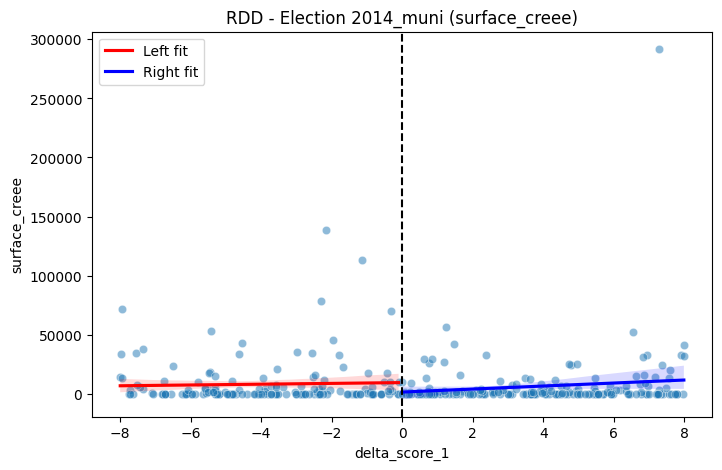

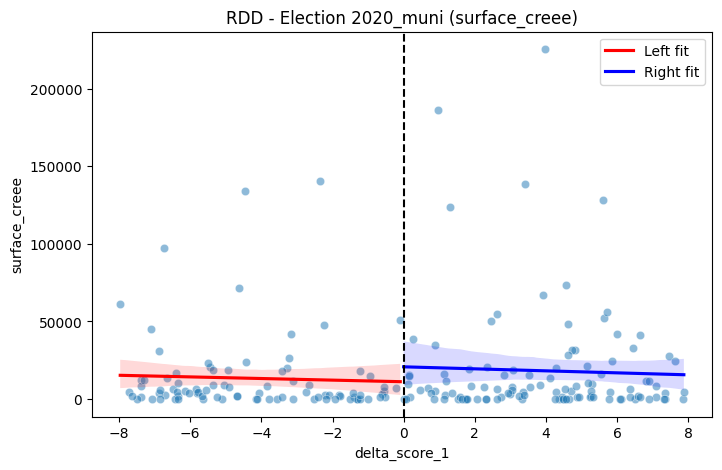

In [38]:
import importlib
import RDD_functions  # importe le module
importlib.reload(RDD_functions)  # recharge le module si tu l'as modifié
from RDD_functions import compute_rdd, plot_rdd 

var='surface_creee'
print(compute_rdd(gdf_RDD, outcome_var=var)["2014_muni"])

plot_rdd(gdf_RDD, outcome_var=var)